In [ ]:
from sklearn.datasets import make_blobs
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter
import torch
import numpy as np
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim


In [ ]:


# Creamos los datos de entrenamiento y validación cruzada
classes = 6
m = 800
std = 0.4
centers = np.array([[-1, 0], [1, 0], [0, 1], [0, -1], [-2, 1], [-2, -1]])
X, y = make_blobs(n_samples=m, centers=centers, cluster_std=std, random_state=2, n_features=2)

# Dividimos el conjunto de datos en train, test y validación
X_train, X_, y_train, y_ = train_test_split(X, y, test_size=0.50, random_state=1)
X_cv, X_test, y_cv, y_test = train_test_split(X_, y_, test_size=0.20, random_state=1)

# Combine todos los datos para estandarizar juntos
X_combined = np.vstack((X_train, X_cv, X_test))
scaler = StandardScaler().fit(X_combined)

# Estandarizamos los datos de entrenamiento, validación cruzada y prueba
X_train_scaled = scaler.transform(X_train)
X_valid_scaled = scaler.transform(X_cv)
X_test_scaled = scaler.transform(X_test)

# Convertimos los datos estandarizados a tensores de PyTorch
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_valid_tensor = torch.tensor(X_valid_scaled, dtype=torch.float32)
y_valid_tensor = torch.tensor(y_cv, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Creamos conjuntos de datos tensoriales
conjunto_entrenamiento = TensorDataset(X_train_tensor, y_train_tensor)
conjunto_validacion = TensorDataset(X_valid_tensor, y_valid_tensor)
conjunto_prueba = TensorDataset(X_test_tensor, y_test_tensor)

# Creamos cargadores de datos para nuestros conjuntos de datos
tamaño_lote = 64
cargador_entrenamiento = DataLoader(conjunto_entrenamiento, batch_size=tamaño_lote, shuffle=True)
cargador_validacion = DataLoader(conjunto_validacion, batch_size=tamaño_lote)
cargador_prueba = DataLoader(conjunto_prueba, batch_size=tamaño_lote)



In [ ]:
#FUNCION AUX PARA DIBUJAR DECISION BOUNDARIES
def plot_decision_boundary(X, y, model, ax):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    #generar predicciones
    Z = model(torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).float())
    Z = torch.argmax(Z, dim=1)
    Z = Z.reshape(xx.shape)

    #dibujar decision boundaries
    ax.contour(xx, yy, Z)

    #dibujar puntos
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired)

    #limites del grafico
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())



Loss: 1.7330
Loss: 1.5900
Loss: 1.4605
Loss: 1.3267
Loss: 1.1852
Loss: 1.0476
Loss: 0.9185
Loss: 0.8010
Loss: 0.6987
Loss: 0.6109
Loss: 0.5422
Loss: 0.4837
Loss: 0.4365
Loss: 0.3984
Loss: 0.3674
Loss: 0.3414
Loss: 0.3197
Loss: 0.3033
Loss: 0.2875
Loss: 0.2752
Loss: 0.2641
Loss: 0.2546
Loss: 0.2480
Loss: 0.2430
Loss: 0.2374
Loss: 0.2309
Loss: 0.2268
Loss: 0.2236
Loss: 0.2212
Loss: 0.2200
Loss: 0.2170
Loss: 0.2130
Loss: 0.2134
Loss: 0.2106
Loss: 0.2084
Loss: 0.2082
Loss: 0.2064
Loss: 0.2054
Loss: 0.2025
Loss: 0.2021
Loss: 0.2010
Loss: 0.2003
Loss: 0.2005
Loss: 0.1979
Loss: 0.2002
Loss: 0.1996
Loss: 0.1985
Loss: 0.1972
Loss: 0.1975
Loss: 0.1972
Loss: 0.1962
Loss: 0.1951
Loss: 0.1958
Loss: 0.1947
Loss: 0.1942
Loss: 0.1943
Loss: 0.1929
Loss: 0.1938
Loss: 0.1936
Loss: 0.1914
Loss: 0.1907
Loss: 0.1911
Loss: 0.1906
Loss: 0.1909
Loss: 0.1939
Loss: 0.1922
Loss: 0.1905
Loss: 0.1901
Loss: 0.1892
Loss: 0.1890
Loss: 0.1888
Loss: 0.1884
Loss: 0.1889
Loss: 0.1899
Loss: 0.1878
Loss: 0.1870
Loss: 0.1872

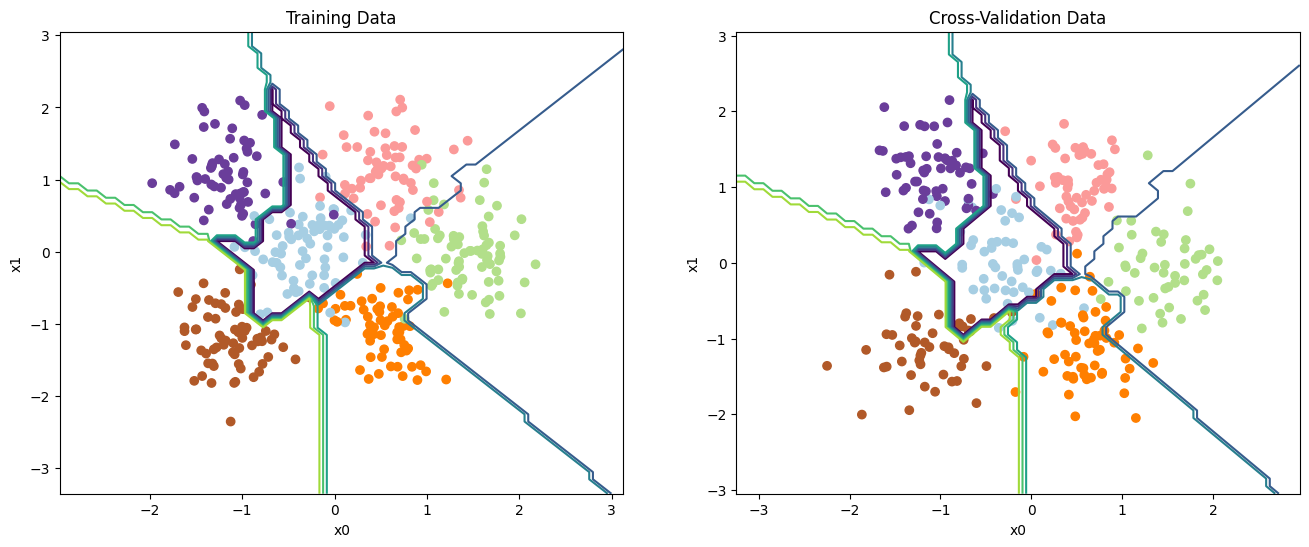

In [ ]:
#MODELO COMPLEJO
#Creamos el modelo de red neuronal
class NeuralNetworkComplex(nn.Module):
    def __init__(self):
        super(NeuralNetworkComplex, self).__init__()
        #capa 1 de 120 individuos
        self.fc1 = nn.Linear(2, 120)
        #capa 2 de 40 individuos
        self.fc2 = nn.Linear(120, 40)
        #capa 3 de 6 individuos
        self.fc3 = nn.Linear(40, 6)

    def forward(self, x):
      #capa 1 con activacion relu
        x = torch.relu(self.fc1(x))
        #capa 2 con activacion relu
        x = torch.relu(self.fc2(x))
        #capa 3 con activacion lineal
        x = self.fc3(x)
        return x

#creamos una instancia de la clase que hemos creado
model_complex = NeuralNetworkComplex()

#definidmos la función de perdida y el optimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_complex.parameters(), lr=0.001)


#ENTRENAMIENTO
num_epochs = 1000
for epoch in range(num_epochs):
    #activamos el modo de entrenamiento del modelo
    model_complex.train()
    running_loss = 0.0
    for inputs, labels in cargador_entrenamiento:
        optimizer.zero_grad()
        #generamos predicciones
        outputs = model_complex(inputs)
        #calculamos la perdida
        loss = criterion(outputs, labels)
        #retropropagamos el error
        loss.backward()
        #actualizamos parametros del optimizador
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
    epoch_loss = running_loss / len(conjunto_entrenamiento)
    print(f'Loss: {epoch_loss:.4f}')

#EVALUAR CON CV
model_complex.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in cargador_validacion:
        outputs = model_complex(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
misclassified_percentage = (1 - accuracy) * 100
print(f'Error CV: {misclassified_percentage:.2f}%')


fig, ax = plt.subplots(1, 2, figsize=(16, 6))
#DIBUJAR TEST
plot_decision_boundary(X_train_scaled, y_train, model_complex, ax[0])
ax[0].set_title('Training Data')
ax[0].set_xlabel('x0')
ax[0].set_ylabel('x1')

#DIBUJAR CV
plot_decision_boundary(X_valid_scaled, y_cv, model_complex, ax[1])
ax[1].set_title('Cross-Validation Data')
ax[1].set_xlabel('x0')
ax[1].set_ylabel('x1')

plt.show()

Error Train: 81.25%
Error Train: 59.50%
Error Train: 54.25%
Error Train: 48.25%
Error Train: 40.50%
Error Train: 36.25%
Error Train: 33.25%
Error Train: 28.50%
Error Train: 23.25%
Error Train: 20.50%
Error Train: 17.00%
Error Train: 15.50%
Error Train: 14.50%
Error Train: 14.00%
Error Train: 13.50%
Error Train: 12.50%
Error Train: 10.50%
Error Train: 10.75%
Error Train: 10.50%
Error Train: 10.50%
Error Train: 9.50%
Error Train: 9.25%
Error Train: 9.25%
Error Train: 9.00%
Error Train: 8.50%
Error Train: 9.00%
Error Train: 9.00%
Error Train: 9.00%
Error Train: 9.00%
Error Train: 8.75%
Error Train: 8.00%
Error Train: 8.50%
Error Train: 8.75%
Error Train: 8.75%
Error Train: 8.75%
Error Train: 8.00%
Error Train: 8.00%
Error Train: 8.50%
Error Train: 8.50%
Error Train: 8.25%
Error Train: 8.25%
Error Train: 8.50%
Error Train: 8.25%
Error Train: 8.00%
Error Train: 7.50%
Error Train: 7.25%
Error Train: 8.00%
Error Train: 8.25%
Error Train: 8.25%
Error Train: 7.50%
Error Train: 8.00%
Error Train

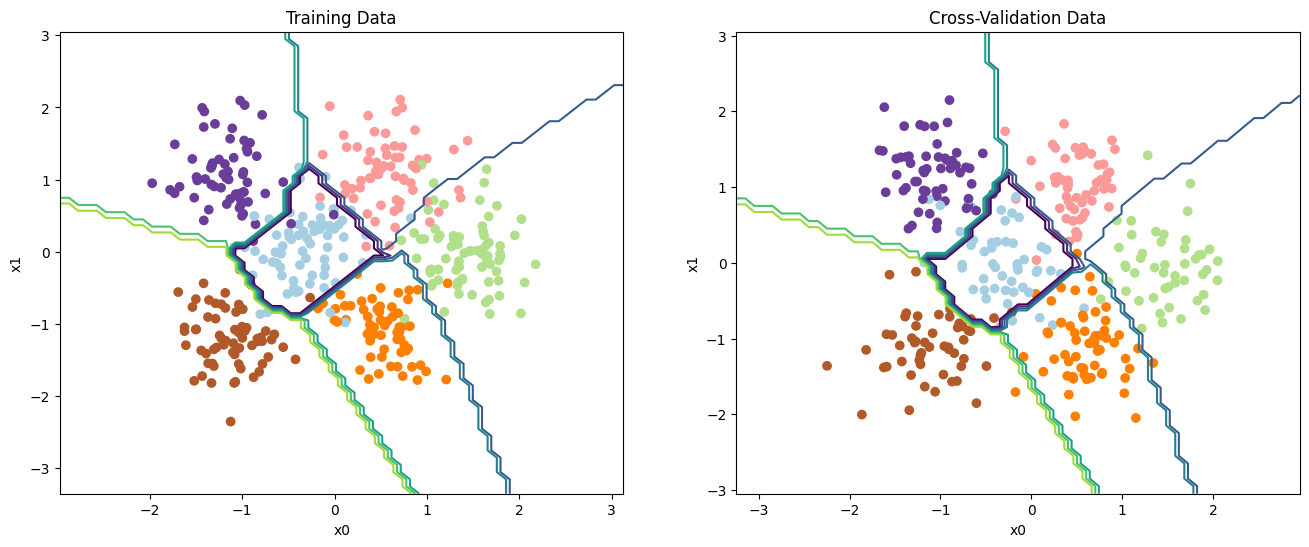

In [ ]:
#MODELO SIMPLE
#Creamos el modelo de red neuronal
class NeuralNetworkSimple(nn.Module):
    def __init__(self):
        super(NeuralNetworkSimple, self).__init__()
        #capa 1 de 6 individuos
        self.fc1 = nn.Linear(2, 6)
        #capa 2 de 6  individuos
        self.fc2 = nn.Linear(6, 6)


    def forward(self, x):
      #capa 1 con activacion relu
        x = torch.relu(self.fc1(x))
        #capa 2 con activacion lineal
        x = self.fc2(x)
        return x

#creamos una instancia de la clase que hemos creado
model = NeuralNetworkSimple()

#definidmos la función de perdida y el optimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)


#ENTRENAMIENTO
num_epochs = 1000
for epoch in range(num_epochs):
    #activamos el modo de entrenamiento del modelo
    model.train()
    running_loss = 0.0
    misclassified_train = 0
    total_train = 0

    for inputs, labels in cargador_entrenamiento:
        optimizer.zero_grad()
        #generamos predicciones
        outputs = model(inputs)
        #calculamos la perdida
        loss = criterion(outputs, labels)
        #retropropagamos el error
        loss.backward()
        #actualizamos parametros del optimizador
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        #calculamos porcentaje de error en entrenamiento
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        misclassified_train += (predicted != labels).sum().item()

    epoch_loss = running_loss / len(conjunto_entrenamiento)
    misclassified_percentage_train = (misclassified_train / total_train) * 100
    print(f'Error Train: {misclassified_percentage_train:.2f}%')

#EVALUAR CON CV
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in cargador_validacion:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
misclassified_percentage = (1 - accuracy) * 100
print(f'Error CV: {misclassified_percentage:.2f}%')


fig, ax = plt.subplots(1, 2, figsize=(16, 6))
#DIBUJAR TEST
plot_decision_boundary(X_train_scaled, y_train, model, ax[0])
ax[0].set_title('Training Data')
ax[0].set_xlabel('x0')
ax[0].set_ylabel('x1')

#DIBUJAR CV
plot_decision_boundary(X_valid_scaled, y_cv, model, ax[1])
ax[1].set_title('Cross-Validation Data')
ax[1].set_xlabel('x0')
ax[1].set_ylabel('x1')

plt.show()


Loss: 1.7255, Error Train: 55.00%
Loss: 1.6371, Error Train: 27.50%
Loss: 1.5580, Error Train: 24.00%
Loss: 1.4756, Error Train: 21.25%
Loss: 1.3901, Error Train: 24.25%
Loss: 1.3004, Error Train: 25.50%
Loss: 1.2120, Error Train: 25.00%
Loss: 1.1308, Error Train: 24.50%
Loss: 1.0545, Error Train: 24.00%
Loss: 0.9870, Error Train: 23.75%
Loss: 0.9303, Error Train: 22.75%
Loss: 0.8817, Error Train: 21.00%
Loss: 0.8428, Error Train: 19.50%
Loss: 0.8095, Error Train: 19.25%
Loss: 0.7823, Error Train: 18.50%
Loss: 0.7608, Error Train: 17.75%
Loss: 0.7441, Error Train: 16.75%
Loss: 0.7297, Error Train: 16.00%
Loss: 0.7177, Error Train: 16.25%
Loss: 0.7068, Error Train: 14.75%
Loss: 0.6987, Error Train: 15.00%
Loss: 0.6931, Error Train: 14.75%
Loss: 0.6879, Error Train: 14.25%
Loss: 0.6842, Error Train: 14.25%
Loss: 0.6814, Error Train: 14.00%
Loss: 0.6794, Error Train: 14.00%
Loss: 0.6784, Error Train: 14.25%
Loss: 0.6776, Error Train: 14.25%
Loss: 0.6772, Error Train: 14.25%
Loss: 0.6770, 

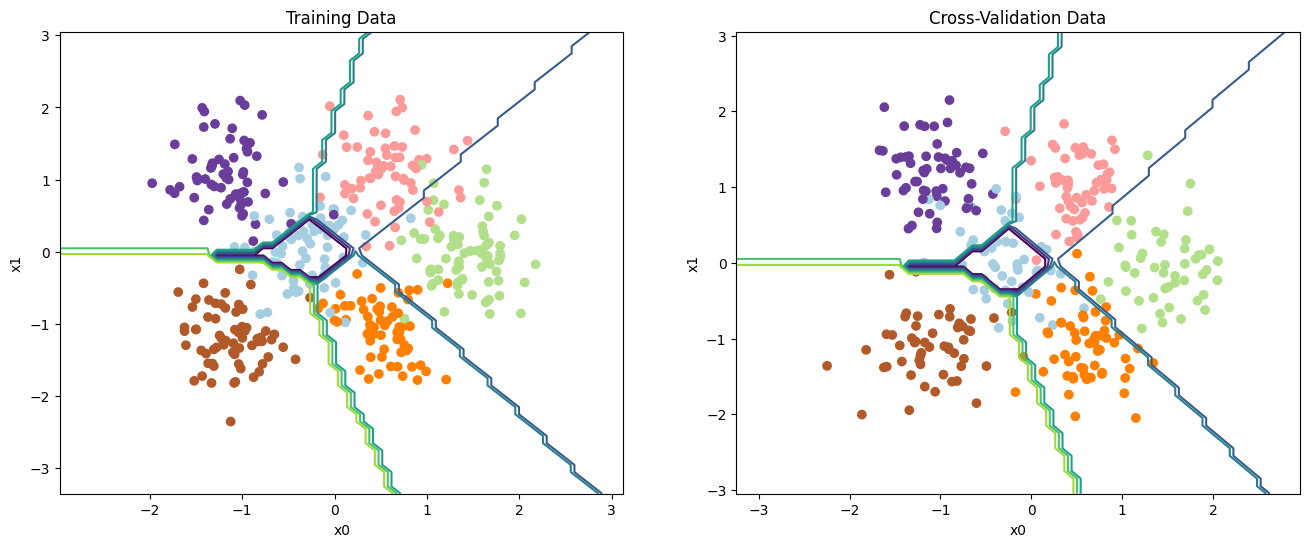

In [ ]:
#MODELO COMPLEJO CON REGULARIZACION L2
class NeuralNetworkComplexReg(nn.Module):
    def __init__(self):
        super(NeuralNetworkComplexReg, self).__init__()
        self.fc1 = nn.Linear(2, 120)
        self.fc2 = nn.Linear(120, 40)
        self.fc3 = nn.Linear(40, 6)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x


model_complex_reg = NeuralNetworkComplexReg()

criterion = nn.CrossEntropyLoss()
optimizer_complex = optim.Adam(model_complex_reg.parameters(), lr=0.001, weight_decay=0.1)


for epoch in range(num_epochs):
    model_complex_reg.train()
    running_loss = 0.0
    misclassified_train = 0
    total_train = 0

    for inputs, labels in cargador_entrenamiento:
        optimizer_complex.zero_grad()
        outputs = model_complex_reg(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_complex.step()
        running_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        misclassified_train += (predicted != labels).sum().item()

    epoch_loss = running_loss / len(conjunto_entrenamiento)
    misclassified_percentage_train = (misclassified_train / total_train) * 100
    print(f'Loss: {epoch_loss:.4f}, Error Train: {misclassified_percentage_train:.2f}%')

#EVALUAR CON CV
model_complex_reg.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in cargador_validacion:
        outputs = model_complex_reg(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
misclassified_percentage = (1 - accuracy) * 100
print(f'Error CV: {misclassified_percentage:.2f}%')


fig, ax = plt.subplots(1, 2, figsize=(16, 6))
#DIBUJAR TEST
plot_decision_boundary(X_train_scaled, y_train, model_complex_reg, ax[0])
ax[0].set_title('Training Data')
ax[0].set_xlabel('x0')
ax[0].set_ylabel('x1')

#DIBUJAR CV
plot_decision_boundary(X_valid_scaled, y_cv, model_complex_reg, ax[1])
ax[1].set_title('Cross-Validation Data')
ax[1].set_xlabel('x0')
ax[1].set_ylabel('x1')

plt.show()


In [ ]:
#MODELO COMPLEJO CON REGULARIZACION L2 ITERANDO VALORES DE LAMBDA
regularization_values = [0.0, 0.001, 0.01, 0.05, 0.1, 0.2, 0.3]

validation_performance = {}
training_performance = {}

for reg_value in regularization_values:
    model_complex = NeuralNetworkComplexReg()
    optimizer_complex = optim.Adam(model_complex.parameters(), lr=0.001, weight_decay=reg_value)

    for epoch in range(num_epochs):
        model_complex.train()
        running_loss = 0.0
        misclassified_train = 0
        total_train = 0

        for inputs, labels in cargador_entrenamiento:
            optimizer_complex.zero_grad()
            outputs = model_complex(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer_complex.step()
            running_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            misclassified_train += (predicted != labels).sum().item()

        epoch_loss = running_loss / len(conjunto_entrenamiento)
        misclassified_percentage_train = (misclassified_train / total_train) * 100

    model_complex.eval()
    correct_cv = 0
    total_cv = 0
    with torch.no_grad():
        for inputs, labels in cargador_validacion:
            outputs = model_complex(inputs)
            _, predicted = torch.max(outputs, 1)
            total_cv += labels.size(0)
            correct_cv += (predicted == labels).sum().item()

    accuracy_cv = correct_cv / total_cv
    misclassified_percentage_cv = (1 - accuracy_cv) * 100

    validation_performance[reg_value] = misclassified_percentage_cv
    training_performance[reg_value] = misclassified_percentage_train


for reg_value in regularization_values:
    print(f'Regularization: {reg_value}, Error Train: {training_performance[reg_value]:.2f}%, Error CV: {validation_performance[reg_value]:.2f}%')


Regularization: 0.0, Error Train: 3.75%, Error CV: 10.31%
Regularization: 0.001, Error Train: 6.00%, Error CV: 7.81%
Regularization: 0.01, Error Train: 7.50%, Error CV: 6.25%
Regularization: 0.05, Error Train: 9.00%, Error CV: 6.56%
Regularization: 0.1, Error Train: 15.75%, Error CV: 12.81%
Regularization: 0.2, Error Train: 81.25%, Error CV: 85.31%
Regularization: 0.3, Error Train: 81.25%, Error CV: 85.31%


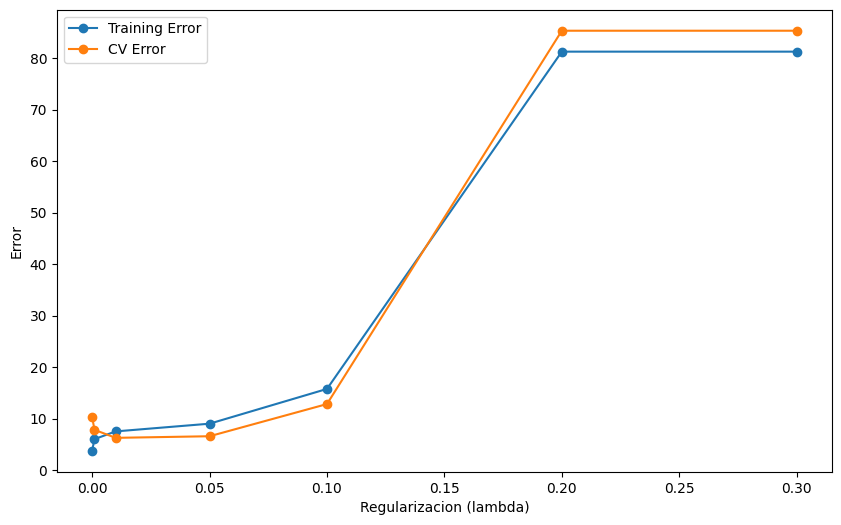

In [ ]:
#DIBUJAMOS GRAFICA PARA ENCONTRAR EL VALOR OPTIMO DE REGULARIZACION
regularization_values = [0.0, 0.001, 0.01, 0.05, 0.1, 0.2, 0.3]
training_errors = [training_performance[reg_value] for reg_value in regularization_values]
cv_errors = [validation_performance[reg_value] for reg_value in regularization_values]

# Dibujar la gráfica
plt.figure(figsize=(10, 6))
plt.plot(regularization_values, training_errors, marker='o', label='Training Error')
plt.plot(regularization_values, cv_errors, marker='o', label='CV Error')
plt.xlabel('Regularizacion (lambda)')
plt.ylabel('Error')
plt.legend()
plt.show()


In [ ]:
#MODELO COMPLEJO CON REGULARIZACION L2 IDEAL
class NeuralNetworkComplexIdeal(nn.Module):
    def __init__(self):
        super(NeuralNetworkComplexIdeal, self).__init__()
        self.fc1 = nn.Linear(2, 120)
        self.fc2 = nn.Linear(120, 40)
        self.fc3 = nn.Linear(40, 6)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x


model_complex_ideal = NeuralNetworkComplexIdeal()

criterion = nn.CrossEntropyLoss()
optimizer_complex = optim.Adam(model_complex_ideal.parameters(), lr=0.001, weight_decay=0.05)


for epoch in range(num_epochs):
    model_complex_ideal.train()
    running_loss = 0.0
    misclassified_train = 0
    total_train = 0

    for inputs, labels in cargador_entrenamiento:
        optimizer_complex.zero_grad()
        outputs = model_complex_ideal(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_complex.step()
        running_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        misclassified_train += (predicted != labels).sum().item()

    epoch_loss = running_loss / len(conjunto_entrenamiento)
    misclassified_percentage_train = (misclassified_train / total_train) * 100
    print(f'Loss: {epoch_loss:.4f}, Error Train: {misclassified_percentage_train:.2f}%')

#EVALUAR CON CV
model_complex_ideal.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in cargador_validacion:
        outputs = model_complex_ideal(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
misclassified_percentage = (1 - accuracy) * 100
print(f'Error CV: {misclassified_percentage:.2f}%')


fig, ax = plt.subplots(1, 2, figsize=(16, 6))
#DIBUJAR TEST
plot_decision_boundary(X_train_scaled, y_train, model_complex_ideal, ax[0])
ax[0].set_title('Training Data')
ax[0].set_xlabel('x0')
ax[0].set_ylabel('x1')

#DIBUJAR CV
plot_decision_boundary(X_valid_scaled, y_cv, model_complex_ideal, ax[1])
ax[1].set_title('Cross-Validation Data')
ax[1].set_xlabel('x0')
ax[1].set_ylabel('x1')

plt.show()


Error en el conjunto de prueba para el MODELO IDEAL: 15.00%
Error en el conjunto de prueba para el MODELO SIMPLE: 15.00%
Error en el conjunto de prueba para el MODELO COMPLEJO REG: 15.00%


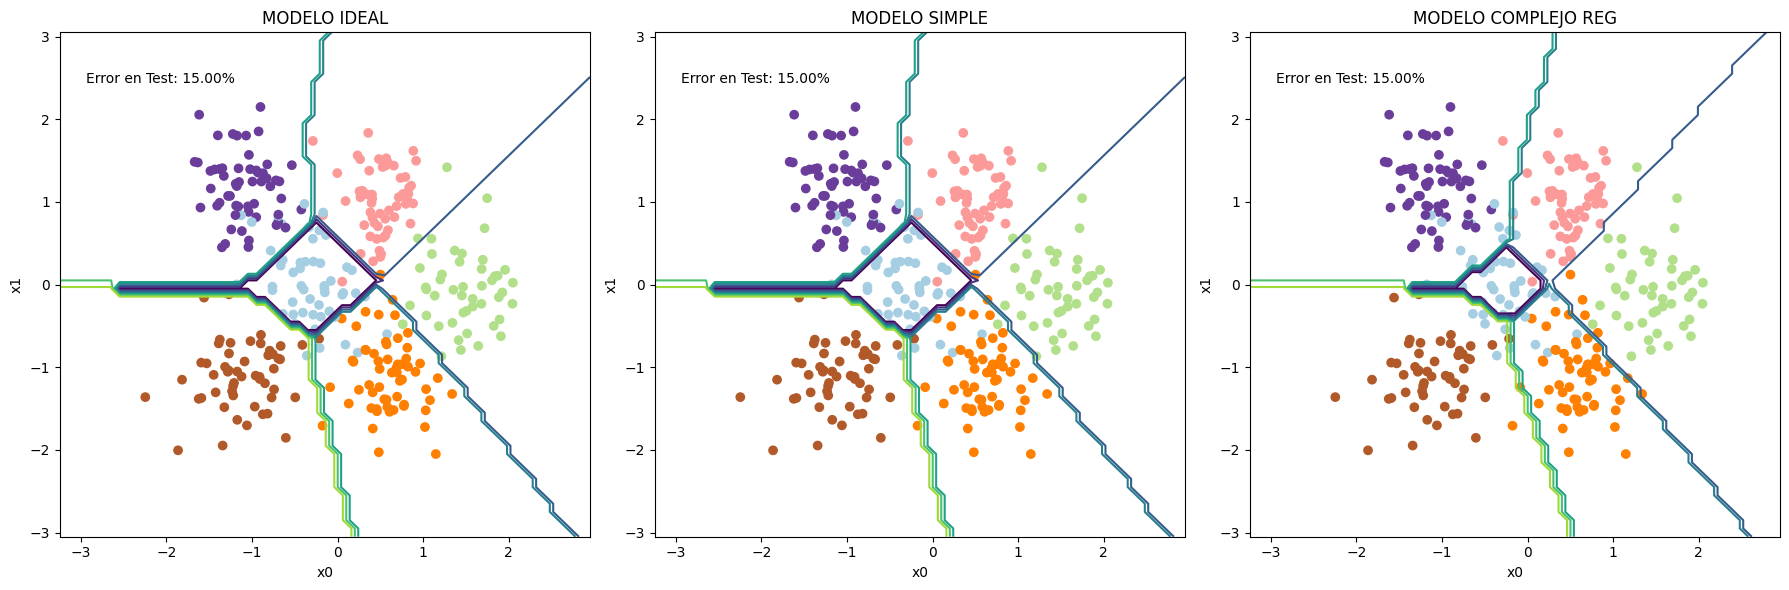

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# MODELO IDEAL
model_complex_ideal.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in cargador_prueba:
        outputs = model_complex_ideal(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
misclassified_percentage = (1 - accuracy) * 100
print(f'Error en el conjunto de prueba para el MODELO IDEAL: {misclassified_percentage:.2f}%')

plot_decision_boundary(X_valid_scaled, y_cv, model_complex_ideal, ax[0])
ax[0].set_title('MODELO IDEAL')
ax[0].set_xlabel('x0')
ax[0].set_ylabel('x1')
ax[0].text(0.05, 0.9, f'Error en Test: {misclassified_percentage:.2f}%', transform=ax[0].transAxes)

# MODELO SIMPLE
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in cargador_prueba:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
misclassified_percentage = (1 - accuracy) * 100
print(f'Error en el conjunto de prueba para el MODELO SIMPLE: {misclassified_percentage:.2f}%')

plot_decision_boundary(X_valid_scaled, y_cv, model, ax[1])
ax[1].set_title('MODELO SIMPLE')
ax[1].set_xlabel('x0')
ax[1].set_ylabel('x1')
ax[1].text(0.05, 0.9, f'Error en Test: {misclassified_percentage:.2f}%', transform=ax[1].transAxes)

# MODELO COMPLEJO
model_complex_reg.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in cargador_prueba:
        outputs = model_complex_reg(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
misclassified_percentage = (1 - accuracy) * 100
print(f'Error en el conjunto de prueba para el MODELO COMPLEJO REG: {misclassified_percentage:.2f}%')

plot_decision_boundary(X_valid_scaled, y_cv, model_complex_reg, ax[2])
ax[2].set_title('MODELO COMPLEJO REG')
ax[2].set_xlabel('x0')
ax[2].set_ylabel('x1')
ax[2].text(0.05, 0.9, f'Error en Test: {misclassified_percentage:.2f}%', transform=ax[2].transAxes)

plt.tight_layout()
plt.show()
